<a href="https://colab.research.google.com/github/AaravJain626/ML-DL-using-PyTorch/blob/main/nn_classification_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##02.nn CLASSIFICATION
classification is precicting wether something is what

# 1.Make Data and Get it ready

In [73]:
import sklearn
from sklearn.datasets import make_circles
import torch
#make 1000 samples
n_samples = 1000

#create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [74]:
len(X), len(y)

(1000, 1000)

In [75]:
print(f"First 5 samples of X{X[:5]}\n")
print(f"First 5 elements of y{y[:5]}\n")

First 5 samples of X[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 elements of y[1 1 1 1 0]



In [76]:
y[:100]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1])

In [77]:
#Making data frame of circle data
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
                        "X2":X[:,1],
                        "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


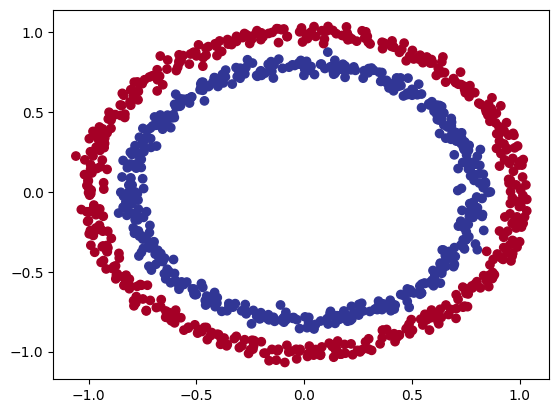

In [78]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);


#1.1 Check Input And Output Shapes


In [79]:
X.shape,y.shape

((1000, 2), (1000,))

In [80]:
X_sample = X[0]
y_sample = y[0]

print(f"X_sample:{X_sample}")
print(f"y_sample:{y_sample}")

print(f"Shape of X_sample:{X_sample.shape}")
print(f"Shape of y_sample:{y_sample.shape}")


X_sample:[0.75424625 0.23148074]
y_sample:1
Shape of X_sample:(2,)
Shape of y_sample:()


#1.2 GET DATA INTO TENSORS AND CREATING TEST AND TRAIN SPLITS

In [81]:
# turning data into pytorch tensors
torch .__version__
X = torch.from_numpy(X) #Converted👍
y = torch.from_numpy(y)

In [82]:
X = X.type(torch.float32)
y = y.type(torch.float32)

In [83]:
X.dtype
y.dtype

torch.float32

In [84]:
#Split the data into training and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2, #means 20% of the data will be test and 80% will be training
                                                 random_state=42)

In [85]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

# 2.Building a model
Building a model to classify blue and red dots(outer and inner(0,1))

1.Building a model by subclassing nn.module

2.Loss fn,optimizer

3.training and test loop

In [86]:
import torch
from torch import nn

#DAG
device   = "cuda" if torch.cuda.is_available() else "cpu" #torch.cuda.is_available=>outputs in Bool
device

'cpu'

In [87]:
##Making model subclassing `nn.Module`
class ClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
#Creating two nn layers
    self.layer_1 = nn.Linear(in_features=2, #takes 2 features in and upscale to 5
                             out_features=5)
    self.layer_2 = nn.Linear(in_features=5, #takes in 5 features from input layer and outputs a single feature(same shape as y)
                             out_features=1)


  #Define a forward method
  def forward(self,X):
    return self.layer_2(self.layer_1(X)) #X→layer_1 → layer_2 → Output

    #instantiate an instance of model class and siTG
model_0 = ClassificationModel().to(device)
print(model_0)

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)


In [88]:
device

'cpu'

In [89]:
next(model_0.parameters()).device

device(type='cpu')

In [90]:
#Replecating the model using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [91]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [92]:
with torch.inference_mode():
 untrained_preds = model_0(X_test.to(device))
print(f"Length of The predictions:{len(untrained_preds)},Shape:{untrained_preds.shape}")
print(f"Length of test samples:{len(X_test)},Shape:{X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of The predictions:200,Shape:torch.Size([200, 1])
Length of test samples:200,Shape:torch.Size([200, 2])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [93]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

#2.1 Setup loss function and optimizer

We are going to use `torch.nn.BCEWithLogitsLoss()`



In [94]:
#Setup a loss function
loss_fn = nn.BCEWithLogitsLoss() #with sigmod builtin S(x) = 1/1+e^-x)

#Optimizer
optimzer = torch.optim.SGD(params=model_0.parameters(),
                           lr=0.1
                           )

In [95]:
#Calculate accuracy -what percentage do model get correct
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

# 3.Training a model

Building a Training loop
* Forward Pass
* Calculate the loss
* Optimizer Zero grad
* Loss Backward(backprop)
* Optimizer step(gd)


##3.1
*Raw Logits→prediction probabilities→prediction labels*

model ouptput→Raw **Logits**
We can convert these **logits** to prediction probabilities by passing them to somekind of activation function(eg.sigmoid,softmax)

We can convert our model's prediction probabilities to *prediction labels* by rounding them or taking the `argmax()`.

In [96]:
model_0.eval()
with torch.inference_mode():
 y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [97]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [98]:
#using sigmoid on logits → S(x) = 1/1+e^-x to logits to convert them to prediction probailities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

In [99]:
torch.round(y_pred_probs).to(device)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

for PP values ,We need to perform range styled rounding

* `y_pred_probs` >= 0.5,`y=1`(1)

* `y_pred_probs` < 0.5,`y=0`(0)

In [100]:
#finding out predicted labels
y_preds = torch.round(y_pred_probs)

#In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#Equality checking
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

#Get Rid of extra dims
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

###3.2 Building a training and testing loop
* `P.P = Prediction Probabilities`

* `P.L = Prediction labels`

In [101]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100 #setting number of epochs

# Put training data to device
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test,y_test.to(device)

#Building Training and evaluation loop
for epoch in range(epochs):
  #training
  model_0.train()

  #Forward pass
  y_logits =  model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits)) #logits → P.P → P.L

  #Calculating Loss/accuracy
  loss = loss_fn(y_logits,
                 y_train) #For loss fn we have BCEWithLogitsLoss which requires raw logits in input parameter
  #if we had normal BCELoss we had to:
  # pass the logits from the activation function
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_preds)
  #zero grad
  optimzer.zero_grad()

  #Backprop
  loss.backward()

  #Gradient descent
  optimzer.step()

  #testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    #Calculate test loss
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_preds)

    #Print what happend
    if epoch % 10 == 0:
      print(f"Epoch Count:{epoch} |Loss:{loss:.5f} |Acc:{acc:.5f}% |Test Loss:{test_loss:.5f} | Test Acc:{test_acc:.2f}% ")

Epoch Count:0 |Loss:0.69796 |Acc:51.87500% |Test Loss:0.69440 | Test Acc:58.00% 
Epoch Count:10 |Loss:0.69590 |Acc:51.25000% |Test Loss:0.69305 | Test Acc:53.00% 
Epoch Count:20 |Loss:0.69490 |Acc:51.62500% |Test Loss:0.69254 | Test Acc:49.50% 
Epoch Count:30 |Loss:0.69435 |Acc:51.12500% |Test Loss:0.69236 | Test Acc:49.50% 
Epoch Count:40 |Loss:0.69401 |Acc:50.87500% |Test Loss:0.69232 | Test Acc:51.00% 
Epoch Count:50 |Loss:0.69378 |Acc:50.25000% |Test Loss:0.69234 | Test Acc:50.00% 
Epoch Count:60 |Loss:0.69362 |Acc:50.00000% |Test Loss:0.69239 | Test Acc:51.50% 
Epoch Count:70 |Loss:0.69351 |Acc:50.25000% |Test Loss:0.69246 | Test Acc:51.00% 
Epoch Count:80 |Loss:0.69342 |Acc:49.87500% |Test Loss:0.69254 | Test Acc:50.00% 
Epoch Count:90 |Loss:0.69336 |Acc:49.87500% |Test Loss:0.69262 | Test Acc:53.00% 


## 4. Make Predictions and Evaluate the model
In order to do so we gotta visualize

We are going to import a function called `plot_decision_boundary()`

In [102]:
import requests
from pathlib import Path
# downloading helper functions from github repo
if Path("helper_functions.py").is_file():
  print("Requirement satisfied")
else:
  print("Install helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Requirement satisfied


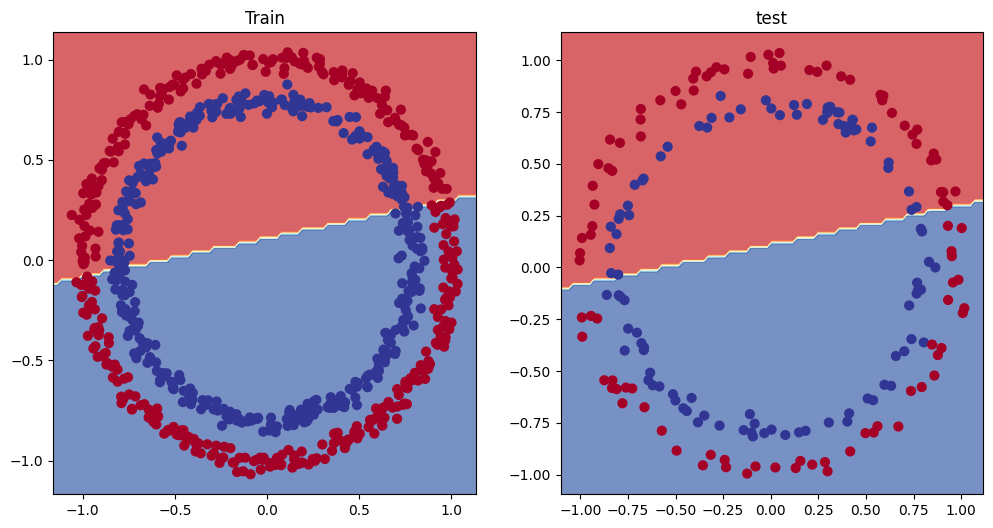

In [103]:
#Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_0,X_test,y_test)

#5. Improving a model
* Add more layers
* add more hidden layers -go from 5 to 10 units
* Fit the model for longer
* Changing the activation function
* Changing the learning rate


In [104]:
class ClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self, X):
    return self.layer_3(nn.ReLU()(self.layer_2(nn.ReLU()(self.layer_1(X)))))

model_1 = ClassificationModel().to(device)
model_1

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [112]:
#Loss Function
loss_fn = nn.BCEWithLogitsLoss()

#Optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                           lr=0.1)

In [118]:
#Loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
y_train = y_train.to(device) #DAG Data
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,
                 y_train)

  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  #testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_preds)
    if epoch % 100 == 0:
      print(f"Epoch Count:{epoch} | Loss:{loss}|accuracy:{acc}|Test Loss:{test_loss}|Test Accuracy:{test_acc}")


Epoch Count:0 | Loss:0.010481324978172779|accuracy:100.0|Test Loss:0.0245082825422287|Test Accuracy:99.5
Epoch Count:100 | Loss:0.010106637142598629|accuracy:100.0|Test Loss:0.02389083057641983|Test Accuracy:99.5
Epoch Count:200 | Loss:0.00975840538740158|accuracy:100.0|Test Loss:0.02331756055355072|Test Accuracy:99.5
Epoch Count:300 | Loss:0.009434081614017487|accuracy:100.0|Test Loss:0.022781889885663986|Test Accuracy:99.5
Epoch Count:400 | Loss:0.009131773374974728|accuracy:100.0|Test Loss:0.022280747070908546|Test Accuracy:99.5
Epoch Count:500 | Loss:0.008848762139678001|accuracy:100.0|Test Loss:0.0218129213899374|Test Accuracy:99.5
Epoch Count:600 | Loss:0.00858279038220644|accuracy:100.0|Test Loss:0.0213774424046278|Test Accuracy:99.5
Epoch Count:700 | Loss:0.008329837583005428|accuracy:100.0|Test Loss:0.02093852125108242|Test Accuracy:99.5
Epoch Count:800 | Loss:0.008092228323221207|accuracy:100.0|Test Loss:0.020532064139842987|Test Accuracy:99.5
Epoch Count:900 | Loss:0.0078684

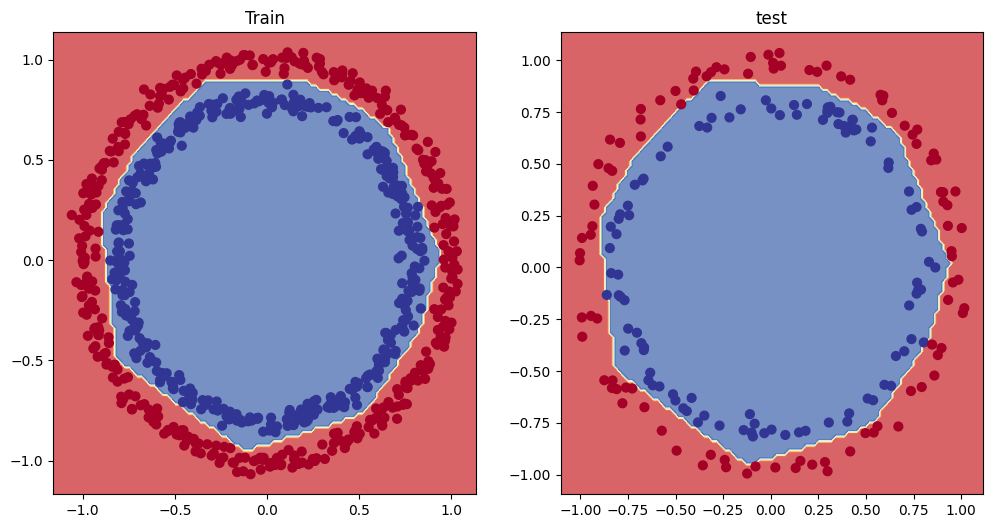

In [120]:
#Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_1,X_test,y_test)